# Notebook 9 — Original A: Comment-Only RoBERTa

Pure baseline: comment text only → RoBERTa → 3-class distribution. No subgroup, no context, no embedding, no FiLM.

In [1]:
import ast, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, confusion_matrix, classification_report
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, pearsonr, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 220)

RANDOM_SEED = 42
MODEL_NAME = "roberta-base"
NUM_LABELS = 3

MAX_LENGTH = 192
BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 1

EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
GRAD_CLIP = 1.0
DROPOUT = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONTEXT_PATH = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_artifacts/context_mapped_examples.parquet")
OUTPUT_DIR = Path("original_a_comment_only_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

print("Device:", DEVICE)
print("Context file:", CONTEXT_PATH)
print("Output directory:", OUTPUT_DIR.resolve())


Device: cuda
Context file: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_artifacts/context_mapped_examples.parquet
Output directory: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/original_a_comment_only_outputs


## 1. Load expanded data

In [2]:
df = pd.read_parquet(CONTEXT_PATH)

print("Dataset:", df.shape)
display(df.head(2))

required_columns = ["comment_id", "split", "subgroup", "text", "target_distribution", "target_majority_label"]
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Rows by split:")
display(df["split"].value_counts())

print("Rows by subgroup:")
display(df["subgroup"].value_counts())

print("Target majority distribution:")
display(df["target_majority_label"].value_counts(normalize=True).sort_index())

print("Unique comments:", df["text"].nunique())
print("Total rows:", len(df))

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"].isin(["validation", "val", "dev"])].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Dataset: (9090, 16)


,experiment,comment_id,split,subgroup,subgroup_count,text,target_distribution,target_majority_label,target_expected_label,retrieved_article_titles,retrieved_page_urls,retrieved_similarities,retrieved_summaries,context_input_text,tweet_token_length,context_input_token_length
0,immigration,7,test,extremely_liberal,1,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill ...,"[1.0, 0.0, 0.0]",0,0.0,[Left-wing politics],[https://en.wikipedia.org/wiki/Left-wing_politics],[0.14819347858428955],"[Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a c...",### COMMENT TO CLASSIFY\n\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and ...,60,197
1,immigration,7,test,liberal,1,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill ...,"[0.0, 0.0, 1.0]",2,2.0,[Left-wing politics],[https://en.wikipedia.org/wiki/Left-wing_politics],[0.14819347858428955],"[Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a c...",### COMMENT TO CLASSIFY\n\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and ...,60,195


Rows by split:


split
train         6360
test          1384
validation    1346
Name: count, dtype: int64

Rows by subgroup:


subgroup
liberal                   2026
neutral                   1512
slightly_liberal          1477
extremely_liberal         1285
slightly_conservative     1079
conservative              1059
extremely_conservative     363
no_opinion                 289
Name: count, dtype: int64

Target majority distribution:


target_majority_label
0    0.734873
1    0.070957
2    0.194169
Name: proportion, dtype: float64

Unique comments: 3797
Total rows: 9090
Train: (6360, 16)
Val: (1346, 16)
Test: (1384, 16)


## 2. Tokenizer and token lengths

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def count_tokens(text):
    return len(tokenizer(text, truncation=False, add_special_tokens=True)["input_ids"])

df["comment_token_length"] = df["text"].apply(count_tokens)

display(pd.DataFrame([{
    "mean": df["comment_token_length"].mean(),
    "median": df["comment_token_length"].median(),
    "p95": df["comment_token_length"].quantile(0.95),
    "max": df["comment_token_length"].max(),
    "pct_over_192": float((df["comment_token_length"] > 192).mean()),
    "pct_over_256": float((df["comment_token_length"] > 256).mean()),
}]))


,mean,median,p95,max,pct_over_192,pct_over_256
0,37.327833,31.0,88.55,187,0.0,0.0


## 3. Dataset and model

In [4]:
def parse_distribution(value):
    if isinstance(value, np.ndarray):
        return value.astype(float).tolist()
    if isinstance(value, list):
        return [float(x) for x in value]
    if isinstance(value, str):
        return [float(x) for x in ast.literal_eval(value)]
    raise TypeError(f"Unsupported distribution type: {type(value)}")


class CommentOnlyDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "target_distribution": torch.tensor(parse_distribution(row["target_distribution"]), dtype=torch.float),
        }


class CommentOnlyRoBERTa(nn.Module):
    def __init__(self, model_name, num_labels=3, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return {
            "logits": logits,
            "log_probs": torch.log_softmax(logits, dim=-1),
            "probs": torch.softmax(logits, dim=-1),
        }


train_loader = DataLoader(CommentOnlyDataset(train_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CommentOnlyDataset(val_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CommentOnlyDataset(test_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})

model = CommentOnlyRoBERTa(MODEL_NAME, NUM_LABELS, DROPOUT).to(DEVICE)

criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

num_update_steps_per_epoch = int(np.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS))
num_training_steps = num_update_steps_per_epoch * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print("Training steps:", num_training_steps)
print("Warmup steps:", num_warmup_steps)


{'input_ids': torch.Size([16, 192]), 'attention_mask': torch.Size([16, 192]), 'target_distribution': torch.Size([16, 3])}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training steps: 3980
Warmup steps: 398


## 4. Metrics

In [5]:
EPS = 1e-12

def kl_divergence(y_true, y_pred):
    y_true = np.clip(y_true, EPS, 1.0)
    y_pred = np.clip(y_pred, EPS, 1.0)
    return np.sum(y_true * np.log(y_true / y_pred), axis=1)

def js_divergence(y_true, y_pred):
    return np.array([jensenshannon(t, p, base=2) ** 2 for t, p in zip(y_true, y_pred)])

def cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, EPS, 1.0)
    return -np.sum(y_true * np.log(y_pred), axis=1)

def expected_scores(distributions):
    return distributions @ np.arange(distributions.shape[1])

def entropy_values(distributions):
    return np.array([entropy(d, base=2) for d in distributions])

def compute_metrics(y_true, y_pred):
    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(y_pred, axis=1)
    true_entropy = entropy_values(y_true)
    pred_entropy = entropy_values(y_pred)

    out = {
        "kl_mean": float(kl_divergence(y_true, y_pred).mean()),
        "js_mean": float(js_divergence(y_true, y_pred).mean()),
        "cross_entropy_mean": float(cross_entropy(y_true, y_pred).mean()),
        "accuracy": float(accuracy_score(true_labels, pred_labels)),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro", zero_division=0)),
        "expected_label_mae": float(mean_absolute_error(expected_scores(y_true), expected_scores(y_pred))),
    }

    if len(np.unique(true_entropy)) > 1 and len(np.unique(pred_entropy)) > 1:
        out["entropy_pearson"] = float(pearsonr(true_entropy, pred_entropy).statistic)
        out["entropy_spearman"] = float(spearmanr(true_entropy, pred_entropy).statistic)
    else:
        out["entropy_pearson"] = np.nan
        out["entropy_spearman"] = np.nan

    return out


## 5. Train

In [6]:
def run_epoch(model, dataloader, optimizer=None, scheduler=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_targets, all_predictions = [], []

    if is_training:
        optimizer.zero_grad()

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        targets = batch["target_distribution"].to(DEVICE)

        with torch.set_grad_enabled(is_training):
            outputs = model(input_ids, attention_mask)
            raw_loss = criterion(outputs["log_probs"], targets)

            if is_training:
                (raw_loss / GRADIENT_ACCUMULATION_STEPS).backward()
                should_step = ((step + 1) % GRADIENT_ACCUMULATION_STEPS == 0) or ((step + 1) == len(dataloader))
                if should_step:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()
                    optimizer.zero_grad()
                    if scheduler is not None:
                        scheduler.step()

        total_loss += raw_loss.item() * input_ids.size(0)
        all_targets.append(targets.detach().cpu().numpy())
        all_predictions.append(outputs["probs"].detach().cpu().numpy())

    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_predictions)
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(total_loss / len(dataloader.dataset))
    return metrics, y_true, y_pred


best_val_kl = float("inf")
best_model_path = OUTPUT_DIR / "original_a_comment_only_best_model.pt"
history = []

for epoch in range(1, EPOCHS + 1):
    train_metrics, _, _ = run_epoch(model, train_loader, optimizer, scheduler)
    val_metrics, _, _ = run_epoch(model, val_loader)

    row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"val_{k}": v for k, v in val_metrics.items()}}
    history.append(row)

    print("=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train KL: {train_metrics['kl_mean']:.4f} | Val KL: {val_metrics['kl_mean']:.4f}")
    print(f"Train JS: {train_metrics['js_mean']:.4f} | Val JS: {val_metrics['js_mean']:.4f}")
    print(f"Val Acc: {val_metrics['accuracy']:.4f} | Val Macro F1: {val_metrics['macro_f1']:.4f}")

    if val_metrics["kl_mean"] < best_val_kl:
        best_val_kl = val_metrics["kl_mean"]
        torch.save(model.state_dict(), best_model_path)
        print("Saved best model")

history_df = pd.DataFrame(history)
display(history_df)
history_df.to_csv(OUTPUT_DIR / "original_a_comment_only_training_history.csv", index=False)


Epoch 1/10
Train KL: 0.7277 | Val KL: 0.5995
Train JS: 0.2889 | Val JS: 0.2245
Val Acc: 0.7608 | Val Macro F1: 0.4644
Saved best model
Epoch 2/10
Train KL: 0.5957 | Val KL: 0.5944
Train JS: 0.2246 | Val JS: 0.2218
Val Acc: 0.7675 | Val Macro F1: 0.4659
Saved best model
Epoch 3/10
Train KL: 0.5409 | Val KL: 0.6281
Train JS: 0.2015 | Val JS: 0.2071
Val Acc: 0.7793 | Val Macro F1: 0.4617
Epoch 4/10
Train KL: 0.4989 | Val KL: 0.5974
Train JS: 0.1854 | Val JS: 0.2185
Val Acc: 0.7860 | Val Macro F1: 0.4826
Epoch 5/10
Train KL: 0.4665 | Val KL: 0.6369
Train JS: 0.1747 | Val JS: 0.2096
Val Acc: 0.7756 | Val Macro F1: 0.4463
Epoch 6/10
Train KL: 0.4361 | Val KL: 0.6727
Train JS: 0.1651 | Val JS: 0.2182
Val Acc: 0.7801 | Val Macro F1: 0.4686
Epoch 7/10
Train KL: 0.4118 | Val KL: 0.7458
Train JS: 0.1570 | Val JS: 0.2064
Val Acc: 0.7823 | Val Macro F1: 0.4545
Epoch 8/10
Train KL: 0.3836 | Val KL: 0.7682
Train JS: 0.1479 | Val JS: 0.2047
Val Acc: 0.7749 | Val Macro F1: 0.4459
Epoch 9/10
Train KL: 0

,epoch,train_kl_mean,train_js_mean,train_cross_entropy_mean,train_accuracy,train_macro_f1,train_expected_label_mae,train_entropy_pearson,train_entropy_spearman,train_loss,val_kl_mean,val_js_mean,val_cross_entropy_mean,val_accuracy,val_macro_f1,val_expected_label_mae,val_entropy_pearson,val_entropy_spearman,val_loss
0,1,0.727721,0.288903,0.760172,0.737736,0.379260,0.643997,0.071804,0.069405,0.727721,0.599489,0.224462,0.633667,0.760773,0.464448,0.493821,0.167975,0.157411,0.599489
1,2,0.595726,0.224607,0.628177,0.774057,0.463416,0.490399,0.137678,0.130426,0.595726,0.594428,0.221847,0.628606,0.767459,0.465851,0.491534,0.115500,0.112934,0.594428
2,3,0.540922,0.201531,0.573373,0.793396,0.491730,0.428204,0.154228,0.139559,0.540922,0.628115,0.207075,0.662293,0.779346,0.461733,0.431696,0.165166,0.157173,0.628115
3,4,0.498852,0.185395,0.531303,0.804560,0.506710,0.383723,0.153800,0.137157,0.498852,0.597362,0.218468,0.631540,0.786033,0.482565,0.471776,0.123158,0.108473,0.597362
4,5,0.466464,0.174670,0.498915,0.813365,0.516778,0.357933,0.152047,0.140710,0.466464,0.636899,0.209649,0.671077,0.775632,0.446303,0.431645,0.141547,0.134271,0.636899
5,6,0.436123,0.165087,0.468573,0.815566,0.521709,0.338109,0.165498,0.148318,0.436123,0.672687,0.218186,0.706865,0.780089,0.468624,0.446844,0.107449,0.096279,0.672687
6,7,0.411809,0.157020,0.444260,0.817453,0.542290,0.323894,0.169728,0.158015,0.411809,0.745805,0.206413,0.779983,0.782318,0.454489,0.411207,0.141825,0.131923,0.745805
7,8,0.383624,0.147924,0.416075,0.824371,0.572219,0.308699,0.180835,0.169158,0.383624,0.768175,0.204652,0.802353,0.774889,0.445948,0.406766,0.134127,0.126357,0.768175
8,9,0.360892,0.142172,0.393343,0.822484,0.608449,0.303212,0.186001,0.173878,0.360892,0.792176,0.208903,0.826354,0.771174,0.483283,0.413044,0.122019,0.119337,0.792176
9,10,0.348064,0.137036,0.380515,0.831447,0.638009,0.296604,0.188084,0.177160,0.348064,0.789001,0.209158,0.823179,0.775632,0.483145,0.414207,0.107272,0.111214,0.789001


## 6. Test and diagnostics

In [7]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_metrics, y_true_test, y_pred_test = run_epoch(model, test_loader)
display(test_metrics)

with open(OUTPUT_DIR / "original_a_comment_only_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

predictions_df = test_df.copy()
predictions_df["true_distribution"] = list(y_true_test)
predictions_df["pred_distribution"] = list(y_pred_test)
predictions_df["pred_majority_label"] = np.argmax(y_pred_test, axis=1)
predictions_df["pred_expected_label"] = expected_scores(y_pred_test)
predictions_df["pred_entropy"] = entropy_values(y_pred_test)
predictions_df["kl"] = kl_divergence(y_true_test, y_pred_test)
predictions_df["js"] = js_divergence(y_true_test, y_pred_test)
predictions_df["cross_entropy"] = cross_entropy(y_true_test, y_pred_test)

predictions_df.to_parquet(OUTPUT_DIR / "original_a_comment_only_test_predictions.parquet", index=False)
predictions_df.to_csv(OUTPUT_DIR / "original_a_comment_only_test_predictions.csv", index=False)

true_labels = np.argmax(y_true_test, axis=1)
pred_labels = np.argmax(y_pred_test, axis=1)

print("Confusion matrix:")
print(confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2]))

print("\\nClassification report:")
print(classification_report(true_labels, pred_labels, labels=[0, 1, 2], zero_division=0))

print("\\nPredicted label distribution:")
display(pd.Series(pred_labels).value_counts(normalize=True).sort_index())

print("\\nTrue label distribution:")
display(pd.Series(true_labels).value_counts(normalize=True).sort_index())

print("\\nAverage target distribution:")
print(np.vstack(predictions_df["true_distribution"].to_numpy()).mean(axis=0))

print("\\nAverage predicted distribution:")
print(np.vstack(predictions_df["pred_distribution"].to_numpy()).mean(axis=0))

print("\\nMean KL by true majority label:")
display(
    predictions_df
    .groupby("target_majority_label")
    .agg(
        n=("comment_id", "count"),
        mean_kl=("kl", "mean"),
        mean_js=("js", "mean"),
        mean_target_entropy=("target_distribution", lambda x: np.mean([entropy(parse_distribution(v), base=2) for v in x])),
        mean_pred_entropy=("pred_entropy", "mean"),
    )
)

print("Average predicted distribution by true majority label:")
for label in [0, 1, 2]:
    subset = predictions_df[predictions_df["target_majority_label"] == label]
    avg_pred = np.vstack(subset["pred_distribution"].to_numpy()).mean(axis=0)
    print(label, avg_pred)

print("\\nPerformance by subgroup, even though subgroup was not given:")
subgroup_rows = []
for subgroup, group in predictions_df.groupby("subgroup"):
    y_true = np.vstack(group["true_distribution"].to_numpy())
    y_pred = np.vstack(group["pred_distribution"].to_numpy())
    subgroup_rows.append({"subgroup": subgroup, "n": len(group), **compute_metrics(y_true, y_pred)})

subgroup_metrics_df = pd.DataFrame(subgroup_rows).sort_values("kl_mean")
display(subgroup_metrics_df)
subgroup_metrics_df.to_csv(OUTPUT_DIR / "original_a_comment_only_subgroup_metrics.csv", index=False)


/tmp/ipykernel_24886/3782265835.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))


{'kl_mean': 0.6090414524078369,
 'js_mean': 0.229568688021754,
 'cross_entropy_mean': 0.6334662437438965,
 'accuracy': 0.7658959537572254,
 'macro_f1': 0.46241926948848894,
 'expected_label_mae': 0.5151512821957286,
 'entropy_pearson': 0.033586010512907015,
 'entropy_spearman': 0.02781256473276488,
 'loss': 0.6090414325970446}

Confusion matrix:
[[918   0 111]
 [ 69   0  26]
 [118   0 142]]
\nClassification report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1029
           1       0.00      0.00      0.00        95
           2       0.51      0.55      0.53       260

    accuracy                           0.77      1384
   macro avg       0.45      0.48      0.46      1384
weighted avg       0.71      0.77      0.74      1384

\nPredicted label distribution:


0    0.79841
2    0.20159
Name: proportion, dtype: float64

\nTrue label distribution:


0    0.743497
1    0.068642
2    0.187861
Name: proportion, dtype: float64

\nAverage target distribution:
[0.731584   0.07428845 0.19412747]
\nAverage predicted distribution:
[0.69855857 0.06250118 0.2389399 ]
\nMean KL by true majority label:


,n,mean_kl,mean_js,mean_target_entropy,mean_pred_entropy
target_majority_label,,,,,
0,1029,0.331809,0.142342,0.035754,0.780522
1,95,2.634838,0.797161,0.052632,0.970445
2,260,0.966047,0.367396,0.026836,1.076642


Average predicted distribution by true majority label:
0 [0.76992255 0.05715901 0.17291833]
1 [0.63310456 0.07114086 0.29575443]
2 [0.44003642 0.08048694 0.47947696]
\nPerformance by subgroup, even though subgroup was not given:


,subgroup,n,kl_mean,js_mean,cross_entropy_mean,accuracy,macro_f1,expected_label_mae,entropy_pearson,entropy_spearman
1,extremely_conservative,46,0.458651,0.190744,0.469196,0.847826,0.546084,0.463043,-0.045772,-0.050529
5,no_opinion,46,0.498670,0.184637,0.517590,0.826087,0.540932,0.407347,-0.185721,-0.157062
0,conservative,163,0.508881,0.194170,0.520813,0.822086,0.502381,0.433446,0.005877,0.008712
6,slightly_conservative,154,0.584088,0.224218,0.595647,0.753247,0.447739,0.516536,-0.110420,-0.108531
3,liberal,308,0.593266,0.224438,0.633528,0.775974,0.469202,0.503386,0.101594,0.101629
2,extremely_liberal,197,0.646417,0.240807,0.667134,0.741117,0.446095,0.534854,0.029211,0.034471
4,neutral,257,0.667891,0.248337,0.701313,0.758755,0.450663,0.558205,0.039605,0.029946
7,slightly_liberal,213,0.677284,0.252995,0.694430,0.718310,0.426877,0.558053,0.021331,0.005282


## 7. Same-comment prediction consistency

In [9]:
predictions_df["pred_tuple"] = predictions_df["pred_distribution"].apply(lambda x: tuple(np.round(np.array(x), 6)))

comment_pred_counts = predictions_df.groupby("comment_id")["pred_tuple"].nunique().describe()
display(comment_pred_counts)

multi = predictions_df.groupby("comment_id")["pred_tuple"].nunique().reset_index(name="n_pred_variants")
print("Comments with multiple rounded prediction variants:")
display(multi[multi["n_pred_variants"] > 1].head())


count    590.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: pred_tuple, dtype: float64

Comments with multiple rounded prediction variants:


,comment_id,n_pred_variants


## Interpretation

This is the pure predictive baseline:

```text
P(label distribution | comment)
```

It cannot produce subgroup counterfactual differences because subgroup identity is not part of the input.


In [11]:
import pandas as pd

pairs = {
    "embedding": {
        "no_context": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_subgroup_metrics.csv",
        "context": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_subgroup_metrics.csv",
    },
    "strong_film": {
        "no_context": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_subgroup_metrics.csv",
        "context": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_subgroup_metrics.csv",
    },
}

def compare_subgroup_metrics(no_context_path, context_path, model_name):
    no_ctx = pd.read_csv(no_context_path)
    ctx = pd.read_csv(context_path)

    no_ctx = no_ctx.add_prefix("no_context_").rename(
        columns={"no_context_subgroup": "subgroup"}
    )
    ctx = ctx.add_prefix("context_").rename(
        columns={"context_subgroup": "subgroup"}
    )

    merged = no_ctx.merge(ctx, on="subgroup", how="inner")

    for metric in ["kl_mean", "js_mean", "accuracy", "macro_f1", "expected_label_mae"]:
        merged[f"delta_{metric}"] = (
            merged[f"context_{metric}"] - merged[f"no_context_{metric}"]
        )

    merged["model_family"] = model_name

    return merged.sort_values("delta_kl_mean")


embedding_comparison = compare_subgroup_metrics(
    pairs["embedding"]["no_context"],
    pairs["embedding"]["context"],
    "embedding",
)

film_comparison = compare_subgroup_metrics(
    pairs["strong_film"]["no_context"],
    pairs["strong_film"]["context"],
    "strong_film",
)

display(embedding_comparison[
    [
        "model_family",
        "subgroup",
        "no_context_n",
        "no_context_kl_mean",
        "context_kl_mean",
        "delta_kl_mean",
        "no_context_macro_f1",
        "context_macro_f1",
        "delta_macro_f1",
        "no_context_expected_label_mae",
        "context_expected_label_mae",
        "delta_expected_label_mae",
    ]
])

display(film_comparison[
    [
        "model_family",
        "subgroup",
        "no_context_n",
        "no_context_kl_mean",
        "context_kl_mean",
        "delta_kl_mean",
        "no_context_macro_f1",
        "context_macro_f1",
        "delta_macro_f1",
        "no_context_expected_label_mae",
        "context_expected_label_mae",
        "delta_expected_label_mae",
    ]
])

,model_family,subgroup,no_context_n,no_context_kl_mean,context_kl_mean,delta_kl_mean,no_context_macro_f1,context_macro_f1,delta_macro_f1,no_context_expected_label_mae,context_expected_label_mae,delta_expected_label_mae
0,embedding,extremely_conservative,46,0.464958,0.401958,-0.063000,0.538095,0.555473,0.017378,0.446751,0.402010,-0.044741
4,embedding,slightly_conservative,154,0.592981,0.558197,-0.034784,0.406450,0.458165,0.051715,0.505752,0.455164,-0.050588
1,embedding,conservative,163,0.486455,0.501368,0.014913,0.510131,0.492813,-0.017318,0.403926,0.387573,-0.016353
7,embedding,neutral,257,0.659621,0.690673,0.031052,0.421328,0.424593,0.003265,0.528488,0.532163,0.003675
6,embedding,slightly_liberal,213,0.656711,0.698896,0.042185,0.405888,0.399490,-0.006398,0.531774,0.535294,0.003520
3,embedding,liberal,308,0.566207,0.628563,0.062355,0.463079,0.439938,-0.023141,0.461034,0.454997,-0.006037
2,embedding,no_opinion,46,0.521677,0.588833,0.067155,0.540932,0.476265,-0.064667,0.413009,0.448306,0.035296
5,embedding,extremely_liberal,197,0.634325,0.757972,0.123647,0.434795,0.385129,-0.049666,0.520534,0.563537,0.043004


,model_family,subgroup,no_context_n,no_context_kl_mean,context_kl_mean,delta_kl_mean,no_context_macro_f1,context_macro_f1,delta_macro_f1,no_context_expected_label_mae,context_expected_label_mae,delta_expected_label_mae
7,strong_film,extremely_liberal,197,0.721895,0.701319,-0.020576,0.407131,0.400603,-0.006528,0.538215,0.515861,-0.022355
6,strong_film,neutral,257,0.673818,0.672532,-0.001287,0.453082,0.415226,-0.037857,0.507779,0.506337,-0.001443
4,strong_film,liberal,308,0.582607,0.584710,0.002103,0.477044,0.458092,-0.018953,0.470300,0.448847,-0.021453
3,strong_film,slightly_conservative,154,0.569174,0.590727,0.021553,0.456205,0.436584,-0.019621,0.454974,0.469857,0.014882
1,strong_film,conservative,163,0.483321,0.509364,0.026044,0.511685,0.490287,-0.021397,0.365159,0.391992,0.026833
5,strong_film,slightly_liberal,213,0.665251,0.698449,0.033197,0.422475,0.397653,-0.024822,0.507564,0.518578,0.011013
2,strong_film,no_opinion,46,0.499141,0.534173,0.035033,0.540932,0.532850,-0.008081,0.382993,0.421583,0.038591
0,strong_film,extremely_conservative,46,0.402275,0.474309,0.072034,0.555473,0.501606,-0.053867,0.385791,0.457664,0.071874


In [12]:
def summarize_subgroup_effects(comparison_df, name):
    print("=" * 80)
    print(name)

    print("Subgroups improved in KL:")
    display(
        comparison_df.loc[
            comparison_df["delta_kl_mean"] < 0,
            ["subgroup", "delta_kl_mean", "delta_macro_f1", "delta_expected_label_mae"]
        ].sort_values("delta_kl_mean")
    )

    print("Subgroups worsened in KL:")
    display(
        comparison_df.loc[
            comparison_df["delta_kl_mean"] > 0,
            ["subgroup", "delta_kl_mean", "delta_macro_f1", "delta_expected_label_mae"]
        ].sort_values("delta_kl_mean", ascending=False)
    )

summarize_subgroup_effects(embedding_comparison, "Embedding: no context vs context")
summarize_subgroup_effects(film_comparison, "Strong FiLM: no context vs context")

Embedding: no context vs context
Subgroups improved in KL:


,subgroup,delta_kl_mean,delta_macro_f1,delta_expected_label_mae
0,extremely_conservative,-0.063000,0.017378,-0.044741
4,slightly_conservative,-0.034784,0.051715,-0.050588


Subgroups worsened in KL:


,subgroup,delta_kl_mean,delta_macro_f1,delta_expected_label_mae
5,extremely_liberal,0.123647,-0.049666,0.043004
2,no_opinion,0.067155,-0.064667,0.035296
3,liberal,0.062355,-0.023141,-0.006037
6,slightly_liberal,0.042185,-0.006398,0.003520
7,neutral,0.031052,0.003265,0.003675
1,conservative,0.014913,-0.017318,-0.016353


Strong FiLM: no context vs context
Subgroups improved in KL:


,subgroup,delta_kl_mean,delta_macro_f1,delta_expected_label_mae
7,extremely_liberal,-0.020576,-0.006528,-0.022355
6,neutral,-0.001287,-0.037857,-0.001443


Subgroups worsened in KL:


,subgroup,delta_kl_mean,delta_macro_f1,delta_expected_label_mae
0,extremely_conservative,0.072034,-0.053867,0.071874
2,no_opinion,0.035033,-0.008081,0.038591
5,slightly_liberal,0.033197,-0.024822,0.011013
1,conservative,0.026044,-0.021397,0.026833
3,slightly_conservative,0.021553,-0.019621,0.014882
4,liberal,0.002103,-0.018953,-0.021453


In [ ]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

TRUE_EL_EC_JS = 0.16448066401642414

models = {
    "Original A": {
        "metrics": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/original_a_comment_only_outputs/original_a_comment_only_test_metrics.json",
        "cf": None,
        "el_ec": None,
    },
    "Context + Token": {
        "metrics": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_test_metrics.json",
        "cf": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_counterfactual_js.csv",
        "el_ec": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_EL_vs_EC_counterfactual.csv",
    },
    "Context + Embedding": {
        "metrics": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_test_metrics.json",
        "cf": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_counterfactual_js.csv",
        "el_ec": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_EL_vs_EC_counterfactual.csv",
    },
    "Context + Strong FiLM": {
        "metrics": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_test_metrics.json",
        "cf": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_counterfactual_js.csv",
        "el_ec": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_EL_vs_EC_counterfactual.csv",
    },
    # Add these if your no-context files exist:
    "Strong FiLM": {
        "metrics": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_test_metrics.json",
        "cf": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_counterfactual_js.csv",
        "el_ec": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_EL_vs_EC_counterfactual.csv",
    },
    "Embedding": {
        "metrics": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_test_metrics.json",
        "cf": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_counterfactual_js.csv",
        "el_ec": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_EL_vs_EC_counterfactual.csv",
    },
}

rows = []

for model_name, paths in models.items():
    row = {"model": model_name}

    metrics_path = Path(paths["metrics"])
    if metrics_path.exists():
        with open(metrics_path) as f:
            metrics = json.load(f)

        row["kl_mean"] = metrics.get("kl_mean")
        row["js_mean"] = metrics.get("js_mean")
        row["macro_f1"] = metrics.get("macro_f1")
        row["accuracy"] = metrics.get("accuracy")
        row["expected_label_mae"] = metrics.get("expected_label_mae")
    else:
        print("Missing metrics:", model_name, metrics_path)

    cf_path = paths["cf"]
    if cf_path is not None and Path(cf_path).exists():
        cf_df = pd.read_csv(cf_path)
        row["mean_counterfactual_js"] = cf_df["mean_pairwise_js"].mean()
        row["median_counterfactual_js"] = cf_df["mean_pairwise_js"].median()
        row["mean_max_pairwise_js"] = cf_df["max_pairwise_js"].mean()
    else:
        row["mean_counterfactual_js"] = 0.0 if model_name == "Original A" else np.nan
        row["median_counterfactual_js"] = 0.0 if model_name == "Original A" else np.nan
        row["mean_max_pairwise_js"] = 0.0 if model_name == "Original A" else np.nan

    el_ec_path = paths["el_ec"]
    if el_ec_path is not None and Path(el_ec_path).exists():
        el_ec_df = pd.read_csv(el_ec_path)
        row["el_ec_model_js"] = el_ec_df["js"].mean()
        row["el_ec_model_js_median"] = el_ec_df["js"].median()
        row["approx_capture_ratio"] = row["el_ec_model_js"] / TRUE_EL_EC_JS
    else:
        row["el_ec_model_js"] = 0.0 if model_name == "Original A" else np.nan
        row["el_ec_model_js_median"] = 0.0 if model_name == "Original A" else np.nan
        row["approx_capture_ratio"] = 0.0 if model_name == "Original A" else np.nan

    rows.append(row)

comparison_df = pd.DataFrame(rows)

comparison_df = comparison_df.sort_values(
    ["approx_capture_ratio", "kl_mean"],
    ascending=[False, True],
)

display(comparison_df)

comparison_df.to_csv("final_model_comparison_table.csv", index=False)
print("Saved: final_model_comparison_table.csv")

,model,kl_mean,js_mean,macro_f1,accuracy,expected_label_mae,mean_counterfactual_js,median_counterfactual_js,mean_max_pairwise_js,el_ec_model_js,el_ec_model_js_median,approx_capture_ratio
3,Context + Strong FiLM,0.621567,0.222306,0.439655,0.772399,0.474821,0.003516,0.001174,0.004257,0.011936,0.010696,0.072570
4,Strong FiLM,0.610134,0.219481,0.461767,0.777457,0.472863,0.001972,0.001690,0.006479,0.003489,0.001654,0.021210
2,Context + Embedding,0.637679,0.220875,0.437165,0.764451,0.487228,0.001718,0.000268,0.002076,0.001101,0.000953,0.006695
1,Context + Token,0.616327,0.229439,0.456479,0.770954,0.508283,0.000216,0.000014,0.000294,0.000077,0.000001,0.000468
0,Original A,0.609041,0.229569,0.462419,0.765896,0.515151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Embedding,0.595919,0.223773,0.448261,0.770231,0.489095,NaN,NaN,NaN,NaN,NaN,NaN


Saved: final_model_comparison_table.csv


In [16]:
import pandas as pd
from pathlib import Path

def compare_subgroup_metrics(no_context_path, context_path, model_name):
    no_ctx = pd.read_csv(no_context_path)
    ctx = pd.read_csv(context_path)

    no_ctx = no_ctx.add_prefix("no_context_").rename(
        columns={"no_context_subgroup": "subgroup"}
    )
    ctx = ctx.add_prefix("context_").rename(
        columns={"context_subgroup": "subgroup"}
    )

    merged = no_ctx.merge(ctx, on="subgroup", how="inner")

    for metric in ["kl_mean", "js_mean", "accuracy", "macro_f1", "expected_label_mae"]:
        merged[f"delta_{metric}"] = (
            merged[f"context_{metric}"] - merged[f"no_context_{metric}"]
        )

    merged["model_family"] = model_name
    return merged.sort_values("delta_kl_mean")


embedding_comparison = compare_subgroup_metrics(
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_subgroup_metrics.csv",
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_subgroup_metrics.csv",
    "Embedding",
)

film_comparison = compare_subgroup_metrics(
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_subgroup_metrics.csv",
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_subgroup_metrics.csv",
    "Strong FiLM",
)

subgroup_context_effects = pd.concat(
    [embedding_comparison, film_comparison],
    ignore_index=True,
)

display(subgroup_context_effects[
    [
        "model_family",
        "subgroup",
        "no_context_kl_mean",
        "context_kl_mean",
        "delta_kl_mean",
        "no_context_macro_f1",
        "context_macro_f1",
        "delta_macro_f1",
        "no_context_expected_label_mae",
        "context_expected_label_mae",
        "delta_expected_label_mae",
    ]
].sort_values(["model_family", "delta_kl_mean"]))

subgroup_context_effects.to_csv("subgroup_context_effects.csv", index=False)
print("Saved: subgroup_context_effects.csv")

,model_family,subgroup,no_context_kl_mean,context_kl_mean,delta_kl_mean,no_context_macro_f1,context_macro_f1,delta_macro_f1,no_context_expected_label_mae,context_expected_label_mae,delta_expected_label_mae
0,Embedding,extremely_conservative,0.464958,0.401958,-0.063000,0.538095,0.555473,0.017378,0.446751,0.402010,-0.044741
1,Embedding,slightly_conservative,0.592981,0.558197,-0.034784,0.406450,0.458165,0.051715,0.505752,0.455164,-0.050588
2,Embedding,conservative,0.486455,0.501368,0.014913,0.510131,0.492813,-0.017318,0.403926,0.387573,-0.016353
3,Embedding,neutral,0.659621,0.690673,0.031052,0.421328,0.424593,0.003265,0.528488,0.532163,0.003675
4,Embedding,slightly_liberal,0.656711,0.698896,0.042185,0.405888,0.399490,-0.006398,0.531774,0.535294,0.003520
5,Embedding,liberal,0.566207,0.628563,0.062355,0.463079,0.439938,-0.023141,0.461034,0.454997,-0.006037
6,Embedding,no_opinion,0.521677,0.588833,0.067155,0.540932,0.476265,-0.064667,0.413009,0.448306,0.035296
7,Embedding,extremely_liberal,0.634325,0.757972,0.123647,0.434795,0.385129,-0.049666,0.520534,0.563537,0.043004
8,Strong FiLM,extremely_liberal,0.721895,0.701319,-0.020576,0.407131,0.400603,-0.006528,0.538215,0.515861,-0.022355
9,Strong FiLM,neutral,0.673818,0.672532,-0.001287,0.453082,0.415226,-0.037857,0.507779,0.506337,-0.001443


Saved: subgroup_context_effects.csv


In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

model_files = {
    "Context + Token": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_true_vs_model_EL_EC.csv",
    "Context + Embedding": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_true_vs_model_EL_EC.csv",
    "Strong FiLM": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_true_vs_model_EL_EC.csv",
    "Context + Strong FiLM": "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_true_vs_model_EL_EC.csv",
}

rows = []
all_comparisons = []

for model_name, path in model_files.items():
    path = Path(path)

    if not path.exists():
        print(f"Missing: {model_name} -> {path}")
        continue

    df = pd.read_csv(path).copy()
    df["model"] = model_name

    # Safety: only evaluate rows where both true and model JS exist.
    df = df.dropna(subset=["true_js", "model_js"])

    # Avoid meaningless capture ratios for true_js = 0.
    nonzero = df[df["true_js"] > 0].copy()
    nonzero["capture_ratio"] = nonzero["model_js"] / nonzero["true_js"]

    if len(df) >= 2 and df["true_js"].nunique() > 1 and df["model_js"].nunique() > 1:
        pearson = pearsonr(df["true_js"], df["model_js"]).statistic
        spearman = spearmanr(df["true_js"], df["model_js"]).statistic
    else:
        pearson = np.nan
        spearman = np.nan

    rows.append({
        "model": model_name,
        "n": len(df),
        "mean_true_js": df["true_js"].mean(),
        "mean_model_js": df["model_js"].mean(),
        "median_model_js": df["model_js"].median(),
        "pearson_true_vs_model_js": pearson,
        "spearman_true_vs_model_js": spearman,
        "mean_capture_ratio_true_js_gt_0": nonzero["capture_ratio"].mean() if len(nonzero) else np.nan,
        "median_capture_ratio_true_js_gt_0": nonzero["capture_ratio"].median() if len(nonzero) else np.nan,
        "n_true_js_gt_0": len(nonzero),
    })

    all_comparisons.append(df)

alignment_df = pd.DataFrame(rows).sort_values(
    ["spearman_true_vs_model_js", "mean_model_js"],
    ascending=[False, False],
)

display(alignment_df)

alignment_df.to_csv("true_vs_model_js_alignment_summary.csv", index=False)
print("Saved: true_vs_model_js_alignment_summary.csv")

,model,n,mean_true_js,mean_model_js,median_model_js,pearson_true_vs_model_js,spearman_true_vs_model_js,mean_capture_ratio_true_js_gt_0,median_capture_ratio_true_js_gt_0,n_true_js_gt_0
1,Context + Embedding,8,0.164481,0.001101,0.000953,0.750262,0.518267,0.029355,0.004740,3
3,Context + Strong FiLM,8,0.164481,0.011936,0.010696,0.271478,0.436436,1.559954,0.034024,3
2,Strong FiLM,8,0.164481,0.005363,0.005273,0.626108,0.354604,0.394758,0.013723,3
0,Context + Token,8,0.164481,0.000077,0.000001,-0.262438,-0.245495,0.000086,0.000112,3


Saved: true_vs_model_js_alignment_summary.csv


In [18]:
combined = pd.concat(all_comparisons, ignore_index=True)

# Rank comments by true human EL/EC disagreement.
top_true_disagreement = (
    combined
    .sort_values("true_js", ascending=False)
    .groupby(["comment_id", "text"], as_index=False)
    .agg(true_js=("true_js", "first"))
    .sort_values("true_js", ascending=False)
    .head(20)
)

display(top_true_disagreement)

# Attach each model's JS to the top true-disagreement comments.
top_model_behavior = top_true_disagreement.merge(
    combined[["model", "comment_id", "model_js"]],
    on="comment_id",
    how="left"
)

display(
    top_model_behavior
    .pivot_table(
        index=["comment_id", "text", "true_js"],
        columns="model",
        values="model_js",
        aggfunc="mean"
    )
    .reset_index()
)

top_model_behavior.to_csv("top_true_disagreement_model_behavior.csv", index=False)
print("Saved: top_true_disagreement_model_behavior.csv")

,comment_id,text,true_js
7,49332,Send all these asses back !,1.000000
0,13695,Yes so every lazy poverty stricken uneducated third world citizen in the entire world from Africa to South America can come here and get welfare and turn America into just as bad of a shithole as their original count...,0.311278
1,20016,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites ou...,0.004567
2,20033,"STOP SUCKING THAT FATASS' DICK, YOU NIGGERLOVING KIKE",0.000000
3,20062,I've always been proud of the Igbo tribe and our culture. Yesterday made me even more proud. You people are too fine abeg. OgbakoUmuIgboDay,0.000000
4,37246,racists b like go back to ur country like ok stop bombing it n maybe i will,0.000000
5,38441,Indian cunts and dickheads orgasming over developing the occupied and annexed Kashmir so they can settle there while the Kashmiri natives remain locked down in their houses with the Indian occupation forces roaming t...,0.000000
6,43958,"Donald trump is the man , he's right if your not happy in the country you are welcomed to fuck of back to where you came from it's not racist or anything of the sort just clear and simple don't matter who you are fuc...",0.000000


model,comment_id,text,true_js,Context + Embedding,Context + Strong FiLM,Context + Token,Strong FiLM
0,13695,Yes so every lazy poverty stricken uneducated third world citizen in the entire world from Africa to South America can come here and get welfare and turn America into just as bad of a shithole as their original count...,0.311278,0.001475,0.010591,4.561319e-05,0.004272
1,20016,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites ou...,0.004567,0.000368,0.021141,5.100696e-07,0.005301
2,20033,"STOP SUCKING THAT FATASS' DICK, YOU NIGGERLOVING KIKE",0.000000,0.000785,0.007604,2.191093e-04,0.003867
3,20062,I've always been proud of the Igbo tribe and our culture. Yesterday made me even more proud. You people are too fine abeg. OgbakoUmuIgboDay,0.000000,0.000130,0.000744,8.015500e-07,0.000790
4,37246,racists b like go back to ur country like ok stop bombing it n maybe i will,0.000000,0.002008,0.007860,3.475054e-04,0.006056
5,38441,Indian cunts and dickheads orgasming over developing the occupied and annexed Kashmir so they can settle there while the Kashmiri natives remain locked down in their houses with the Indian occupation forces roaming t...,0.000000,0.000243,0.019772,1.511377e-06,0.007534
6,43958,"Donald trump is the man , he's right if your not happy in the country you are welcomed to fuck of back to where you came from it's not racist or anything of the sort just clear and simple don't matter who you are fuc...",0.000000,0.001120,0.010801,2.762387e-07,0.005244
7,49332,Send all these asses back !,1.000000,0.002679,0.016977,5.877474e-07,0.009841


Saved: top_true_disagreement_model_behavior.csv


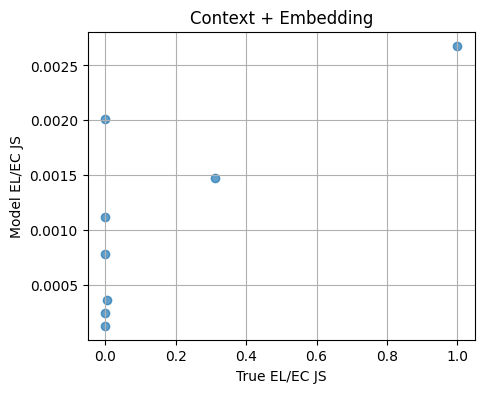

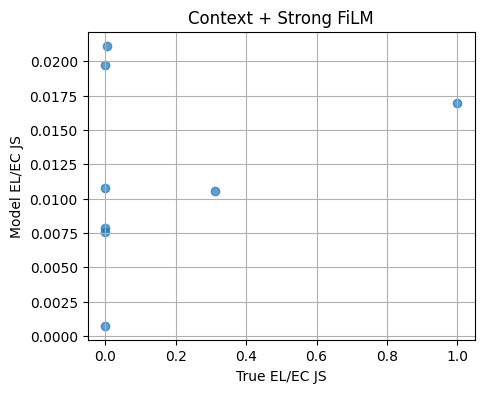

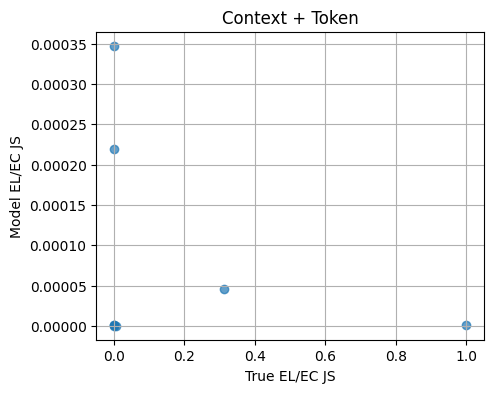

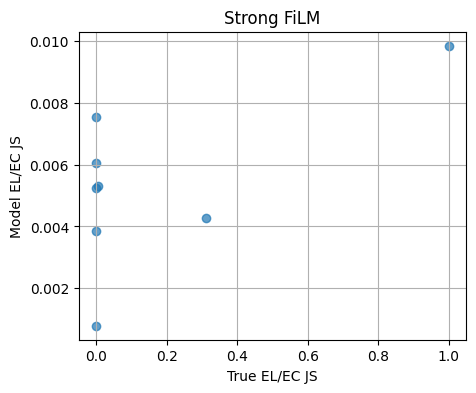

In [19]:
for model_name, df in combined.groupby("model"):
    plt.figure(figsize=(5, 4))
    plt.scatter(df["true_js"], df["model_js"], alpha=0.7)
    plt.xlabel("True EL/EC JS")
    plt.ylabel("Model EL/EC JS")
    plt.title(model_name)
    plt.grid(True)
    plt.show()

In [20]:
from scipy.stats import pearsonr, spearmanr

pearsonr(df["true_js"], df["model_js"])
spearmanr(df["true_js"], df["model_js"])

SignificanceResult(statistic=0.3546040716334876, pvalue=0.38875148770795215)

In [21]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression

model_files = {
    "Context + Token":
        "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_true_vs_model_EL_EC.csv",

    "Context + Embedding":
        "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_true_vs_model_EL_EC.csv",

    "Strong FiLM":
        "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_true_vs_model_EL_EC.csv",

    "Context + Strong FiLM":
        "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_true_vs_model_EL_EC.csv",
}

results = []

for model_name, path in model_files.items():

    df = pd.read_csv(path)

    df = df.dropna(subset=["true_js", "model_js"])

    if len(df) < 3:
        continue

    x = df["true_js"].values
    y = df["model_js"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    reg = LinearRegression()
    reg.fit(x.reshape(-1, 1), y)

    r2 = reg.score(x.reshape(-1, 1), y)

    results.append({
        "model": model_name,
        "n_pairs": len(df),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "r2": r2,
        "mean_model_js": y.mean(),
        "max_model_js": y.max(),
    })

alignment_df = pd.DataFrame(results)

display(
    alignment_df.sort_values(
        "spearman_rho",
        ascending=False
    )
)

alignment_df.to_csv(
    "true_vs_model_js_correlations.csv",
    index=False
)

print("Saved: true_vs_model_js_correlations.csv")

,model,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p,r2,mean_model_js,max_model_js
1,Context + Embedding,8,0.750262,0.032011,0.518267,0.188236,0.562893,0.001101,0.002679
3,Context + Strong FiLM,8,0.271478,0.515437,0.436436,0.279658,0.073700,0.011936,0.021141
2,Strong FiLM,8,0.626108,0.096768,0.354604,0.388751,0.392012,0.005363,0.009841
0,Context + Token,8,-0.262438,0.530056,-0.245495,0.557857,0.068874,0.000077,0.000348


Saved: true_vs_model_js_correlations.csv


In [22]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression

results = []

for model_name, path in model_files.items():

    df = pd.read_csv(path)

    df = df.dropna(subset=["true_js", "model_js"])

    # remove the perfect disagreement point
    df = df[df["true_js"] < 0.95]

    if len(df) < 3:
        continue

    x = df["true_js"].values
    y = df["model_js"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    reg = LinearRegression()
    reg.fit(x.reshape(-1,1), y)

    r2 = reg.score(x.reshape(-1,1), y)

    results.append({
        "model": model_name,
        "pearson_r": pearson_r,
        "spearman_rho": spearman_rho,
        "r2": r2,
        "mean_model_js": y.mean()
    })

robust_df = pd.DataFrame(results)

display(
    robust_df.sort_values(
        "spearman_rho",
        ascending=False
    )
)

,model,pearson_r,spearman_rho,r2,mean_model_js
3,Context + Strong FiLM,-0.029662,0.400892,0.000880,0.011216
1,Context + Embedding,0.374949,0.222718,0.140587,0.000876
2,Strong FiLM,-0.092901,-0.044544,0.008631,0.004723
0,Context + Token,-0.138056,-0.089087,0.019059,0.000088


In [23]:
import pandas as pd

df = pd.read_csv(
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_EL_vs_EC_counterfactual.csv"
)

cols = [
    "comment_id",
    "text",
    "js",
    "pred_extremely_liberal",
    "pred_extremely_conservative",
    "context_extremely_liberal",
    "context_extremely_conservative",
]

top_examples = df.sort_values("js", ascending=False)[cols].head(8)

display(top_examples)

,comment_id,text,js,pred_extremely_liberal,pred_extremely_conservative,context_extremely_liberal,context_extremely_conservative
1,20016,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites ou...,0.021141,[0.2028104 0.08258216 0.7146075 ],[0.10552359 0.0401975 0.8542789 ],### COMMENT TO CLASSIFY\nKeep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of t...,### COMMENT TO CLASSIFY\nKeep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of t...
5,38441,Indian cunts and dickheads orgasming over developing the occupied and annexed Kashmir so they can settle there while the Kashmiri natives remain locked down in their houses with the Indian occupation forces roaming t...,0.019772,[0.48870242 0.17469715 0.3366004 ],[0.3883188 0.11503803 0.49664316],### COMMENT TO CLASSIFY\nIndian cunts and dickheads orgasming over developing the occupied and annexed Kashmir so they can settle there while the Kashmiri natives remain locked down in their houses with the Indian oc...,### COMMENT TO CLASSIFY\nIndian cunts and dickheads orgasming over developing the occupied and annexed Kashmir so they can settle there while the Kashmiri natives remain locked down in their houses with the Indian oc...
7,49332,Send all these asses back !,0.016977,[0.5631097 0.16088861 0.27600172],[0.47034317 0.11097186 0.41868502],"### COMMENT TO CLASSIFY\nSend all these asses back !\n\n### ANNOTATOR IDEOLOGY\nextremely_liberal\n\n### RETRIEVED BACKGROUND\nFree migration:\nThe concept of free migration has been debated globally, with various pe...",### COMMENT TO CLASSIFY\nSend all these asses back !\n\n### ANNOTATOR IDEOLOGY\nextremely_conservative\n\n### RETRIEVED BACKGROUND\nOpposition to immigration:\nNational identity plays a significant role in shaping at...
6,43958,"Donald trump is the man , he's right if your not happy in the country you are welcomed to fuck of back to where you came from it's not racist or anything of the sort just clear and simple don't matter who you are fuc...",0.010801,[0.5746612 0.17407703 0.2512618 ],[0.5120896 0.12820059 0.3597098 ],"### COMMENT TO CLASSIFY\nDonald trump is the man , he's right if your not happy in the country you are welcomed to fuck of back to where you came from it's not racist or anything of the sort just clear and simple don...","### COMMENT TO CLASSIFY\nDonald trump is the man , he's right if your not happy in the country you are welcomed to fuck of back to where you came from it's not racist or anything of the sort just clear and simple don..."
0,13695,Yes so every lazy poverty stricken uneducated third world citizen in the entire world from Africa to South America can come here and get welfare and turn America into just as bad of a shithole as their original count...,0.010591,[0.6127877 0.17138977 0.2158225 ],[0.55216587 0.12864332 0.31919083],### COMMENT TO CLASSIFY\nYes so every lazy poverty stricken uneducated third world citizen in the entire world from Africa to South America can come here and get welfare and turn America into just as bad of a shithol...,### COMMENT TO CLASSIFY\nYes so every lazy poverty stricken uneducated third world citizen in the entire world from Africa to South America can come here and get welfare and turn America into just as bad of a shithol...
4,37246,racists b like go back to ur country like ok stop bombing it n maybe i will,0.007860,[0.54402477 0.18472187 0.27125338],[0.5180952 0.12822384 0.35368094],### COMMENT TO CLASSIFY\nracists b like go back to ur country like ok stop bombing it n maybe i will\n\n### ANNOTATOR IDEOLOGY\nextremely_liberal\n\n### RETRIEVED BAC